# Student Score Prediction

## Project Objective
Predict the **Performance Index** of students using study habits and related academic factors.

This notebook follows the required workflow:

- Data loading and understanding
- Data cleaning and quality checks
- Basic + meaningful visualizations
- Train/test split
- **Linear Regression** as the main model
- Evaluation using **R², MAE, RMSE, and MAPE**
- Actual vs Predicted visualization
- **Bonus:** Polynomial Regression
- **Bonus:** Feature-combination experiments
- Residual analysis and final conclusions

> **Important:** The task highlights `Hours Studied`, so it is used as the required baseline feature. We then test whether additional features improve prediction.

## 1. Import Libraries

We use a small, explainable stack:

- **Pandas / NumPy** → data handling and numerical work
- **Matplotlib** → clear, customized visualizations
- **Scikit-learn** → splitting, regression, and evaluation

The plots use clean spacing, readable labels, light grids, and minimal chart decoration so the important patterns are easy to see.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error)
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.titlesize": 16,
    "axes.labelsize": 12,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.alpha": 0.25,
    "font.size": 11,
})

## 2. Load the Dataset

We first locate the CSV, load it into a DataFrame, and keep a separate copy of the raw data.

**Why?** Keeping the raw version lets us compare the dataset before and after cleaning.

In [2]:
data_path = Path("StudentPerformance.csv")
if not data_path.exists():
    data_path = Path("/mnt/data/StudentPerformance.csv")

if not data_path.exists():
    raise FileNotFoundError("StudentPerformance.csv was not found in the current folder or /mnt/data.")

df_raw = pd.read_csv(data_path)
df = df_raw.copy()

print(f"Raw dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
display(df.head())

Raw dataset shape: 10,000 rows × 6 columns


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.000
1,4,82,No,4,2,65.000
2,8,51,Yes,7,2,45.000
3,5,52,Yes,5,2,36.000
4,7,75,No,8,5,66.000


## 3. Understand the Dataset

Before modeling, we check:

- column names and data types,
- summary statistics,
- missing values,
- duplicates,
- and categorical values.

This prevents us from training a model before understanding the data quality.

In [3]:
print("Columns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
display(df.isna().sum().rename("Missing Values").to_frame())

print(f"\nDuplicate rows: {df.duplicated().sum()}")

print("\nCategorical values in Extracurricular Activities:")
print(df["Extracurricular Activities"].value_counts(dropna=False))

print("\nSummary statistics:")
display(df.describe().T)

Columns:
['Hours Studied', 'Previous Scores', 'Extracurricular Activities', 'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index']

Data types:
Hours Studied                         int64
Previous Scores                       int64
Extracurricular Activities              str
Sleep Hours                           int64
Sample Question Papers Practiced      int64
Performance Index                   float64
dtype: object

Missing values:


,Missing Values
Hours Studied,0
Previous Scores,0
Extracurricular Activities,0
Sleep Hours,0
Sample Question Papers Practiced,0
Performance Index,0



Duplicate rows: 127

Categorical values in Extracurricular Activities:
Extracurricular Activities
No     5052
Yes    4948
Name: count, dtype: int64

Summary statistics:


,count,mean,std,min,25%,50%,75%,max
Hours Studied,10000.000,4.993,2.589,1.000,3.000,5.000,7.000,9.000
Previous Scores,10000.000,69.446,17.343,40.000,54.000,69.000,85.000,99.000
Sleep Hours,10000.000,6.531,1.696,4.000,5.000,7.000,8.000,9.000
Sample Question Papers Practiced,10000.000,4.583,2.867,0.000,2.000,5.000,7.000,9.000
Performance Index,10000.000,55.225,19.213,10.000,40.000,55.000,71.000,100.000


### Data-quality finding

The raw file contains **10,000 rows and 6 columns**. There are **no missing values**, but there are **127 exact duplicate rows**.

The dataset also contains one categorical variable, `Extracurricular Activities`, with two values: `Yes` and `No`.

So the main cleaning actions are duplicate removal and categorical encoding. We do **not** remove observations just because they are extreme: an unusual student is not automatically a data error.

## 4. Data Cleaning

Steps performed:

1. Remove exact duplicate rows.
2. Convert `Extracurricular Activities` from `Yes/No` to `1/0`.
3. Re-check the data after cleaning.

The target contains no zero values, which also means **MAPE can be used safely** for this dataset.

In [4]:
duplicates_before = df.duplicated().sum()
df = df.drop_duplicates().reset_index(drop=True)

df["Extracurricular Activities"] = df["Extracurricular Activities"].map({"No": 0, "Yes": 1})

if df["Extracurricular Activities"].isna().any():
    raise ValueError("Unexpected category found in Extracurricular Activities.")

print(f"Duplicate rows removed: {duplicates_before}")
print(f"Rows after cleaning: {len(df):,}")
print(f"Missing values after cleaning: {df.isna().sum().sum()}")
print(f"Zero target values: {(df['Performance Index'] == 0).sum()}")

display(df.head())

Duplicate rows removed: 127
Rows after cleaning: 9,873
Missing values after cleaning: 0
Zero target values: 0


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.000
1,4,82,0,4,2,65.000
2,8,51,1,7,2,45.000
3,5,52,1,5,2,36.000
4,7,75,0,8,5,66.000


## 5. Outlier Check

A box plot is used to **inspect** the numerical ranges.

We are not using the box plot as an automatic deletion rule. The goal is to ask whether the values look plausible and whether extreme observations could be legitimate students.

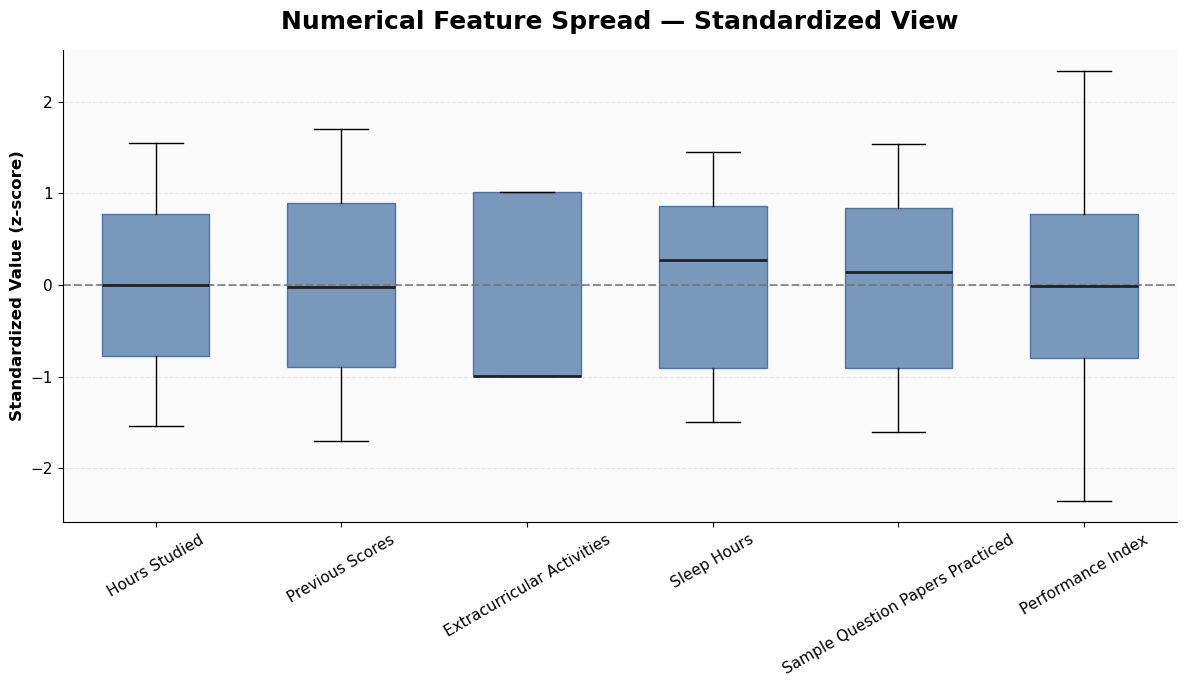

In [5]:
numeric_cols = df.select_dtypes(include=np.number).columns
scaled_numeric = (df[numeric_cols] - df[numeric_cols].mean()) / df[numeric_cols].std()

fig, ax = plt.subplots(figsize=(12, 7))

bp = ax.boxplot(
    [scaled_numeric[c] for c in numeric_cols],
    tick_labels=numeric_cols,
    patch_artist=True,
    widths=0.58,
    flierprops=dict(marker="o", markersize=3.5, alpha=0.4))
for box in bp["boxes"]:
    box.set_facecolor("#4C78A8")
    box.set_alpha(0.75)
    box.set_edgecolor("#2F5597")

for median in bp["medians"]:
    median.set_color("#222222")
    median.set_linewidth(2)

ax.axhline(0, linestyle="--", color="#777777", linewidth=1.5, alpha=0.8)
ax.set_title("Numerical Feature Spread — Standardized View", fontsize=18, fontweight="bold", pad=15)
ax.set_ylabel("Standardized Value (z-score)", fontweight="bold")
ax.tick_params(axis="x", rotation=30)
ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_facecolor("#FAFAFA")

plt.tight_layout()
plt.show()

### Interpretation

Because the numerical features use different scales (for example, scores are much larger than sleep hours), the original raw-value box plot is not ideal for comparing spread on one axis. This standardized view puts every feature on a common scale.

Most features have compact and plausible distributions, with no evidence of extreme values that clearly look like data-entry errors. The points beyond the whiskers represent relatively unusual observations, but unusual does not automatically mean invalid.

**Decision:** keep the cleaned observations. We do not remove these points because the dataset gives no evidence that they are erroneous.

# Exploratory Data Analysis (EDA)

The visualizations below answer specific questions about the data. The goal is not to create many charts; it is to use each chart to learn something useful before modeling.

## 6. Performance Index Distribution

**Question:** What does the target look like overall?

A histogram with the mean and median helps us see the center and spread of student performance.

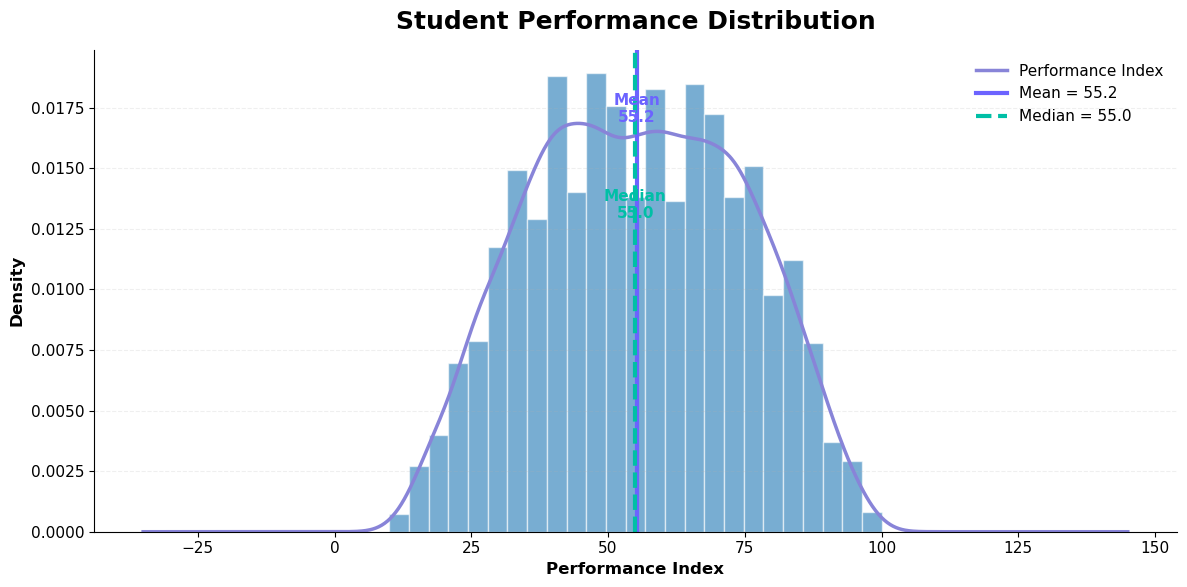

Mean   : 55.22
Median : 55.00
Min    : 10.00
Max    : 100.00


In [6]:
target = "Performance Index"

mean_score = df[target].mean()
median_score = df[target].median()

fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(df[target], bins=25, density=True, alpha=0.6, edgecolor="white")
df[target].plot.kde(ax=ax, color="#8884D8", linewidth=2.5)

ax.axvline(
    mean_score, color="#6C63FF", linewidth=3,
    label=f"Mean = {mean_score:.1f}")

ax.axvline(
    median_score, color="#00BFA6", linewidth=3,
    linestyle="--", label=f"Median = {median_score:.1f}")

ax.text(mean_score, ax.get_ylim()[1] * 0.85,
        f"Mean\n{mean_score:.1f}",
        color="#6C63FF", fontweight="bold", ha="center")

ax.text(median_score, ax.get_ylim()[1] * 0.65,
        f"Median\n{median_score:.1f}",
        color="#00BFA6", fontweight="bold", ha="center")

ax.set_title("Student Performance Distribution",
             fontsize=18, fontweight="bold", pad=15)

ax.set_xlabel("Performance Index", fontweight="bold")
ax.set_ylabel("Density", fontweight="bold")

ax.legend(frameon=False)
ax.grid(axis="y", linestyle="--", alpha=0.2)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

print(f"Mean   : {mean_score:.2f}")
print(f"Median : {median_score:.2f}")
print(f"Min    : {df[target].min():.2f}")
print(f"Max    : {df[target].max():.2f}")

### Interpretation

The target is centered around the mid-50s, with a mean of about **55.2** and a median of **55**. This tells us what a typical student looks like, while the broad range confirms that there is substantial variation for a regression model to explain.

## 7. Study Hours vs Performance — Trend View

**Question:** Does more study time correspond to better performance?

Because `Hours Studied` is the feature explicitly requested in the task, this is the main relationship to inspect first.

Instead of plotting 10,000 overlapping points, we aggregate by study hour and show the **average + median + variability**.

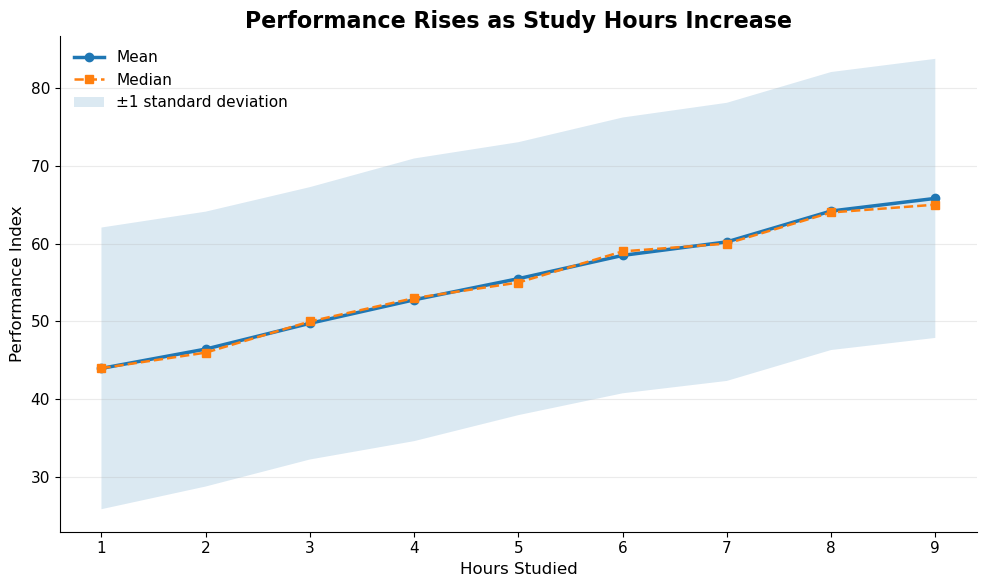

,Hours Studied,Mean,Median,Std,Count
0,1,43.980,44.000,18.090,1133
1,2,46.450,46.000,17.650,1077
2,3,49.760,50.000,17.490,1110
3,4,52.780,53.000,18.150,1071
4,5,55.500,55.000,17.530,1069
5,6,58.480,59.000,17.710,1122
6,7,60.220,60.000,17.860,1118
7,8,64.180,64.000,17.850,1074
8,9,65.810,65.000,17.920,1099


In [7]:
hours_summary = (
    df.groupby("Hours Studied")[target]
      .agg(Mean="mean", Median="median", Std="std", Count="count")
      .reset_index())

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(hours_summary["Hours Studied"], hours_summary["Mean"], marker="o", linewidth=2.5, label="Mean")
ax.plot(hours_summary["Hours Studied"], hours_summary["Median"], marker="s", linewidth=1.8, linestyle="--", label="Median")
ax.fill_between(
    hours_summary["Hours Studied"],
    hours_summary["Mean"] - hours_summary["Std"],
    hours_summary["Mean"] + hours_summary["Std"],
    alpha=0.16,
    label="±1 standard deviation",)

ax.set_title("Performance Rises as Study Hours Increase")
ax.set_xlabel("Hours Studied")
ax.set_ylabel("Performance Index")
ax.set_xticks(hours_summary["Hours Studied"])
ax.legend(frameon=False)
ax.grid(axis="y")
plt.tight_layout()
plt.show()

display(hours_summary.round(2))

### Interpretation

The average Performance Index generally increases as study hours increase, showing a **positive relationship** between study time and performance.

However, the spread around each hour level is still wide. That matters: students who study the same number of hours can have noticeably different performance. This suggests that **study hours alone will not explain the full target**.

## 8. Previous Scores vs Performance — Density View

**Question:** Is previous academic performance a stronger indicator than study hours?

A hexbin plot is useful here because thousands of scatter points can overlap. Darker / denser areas show where many students are concentrated.

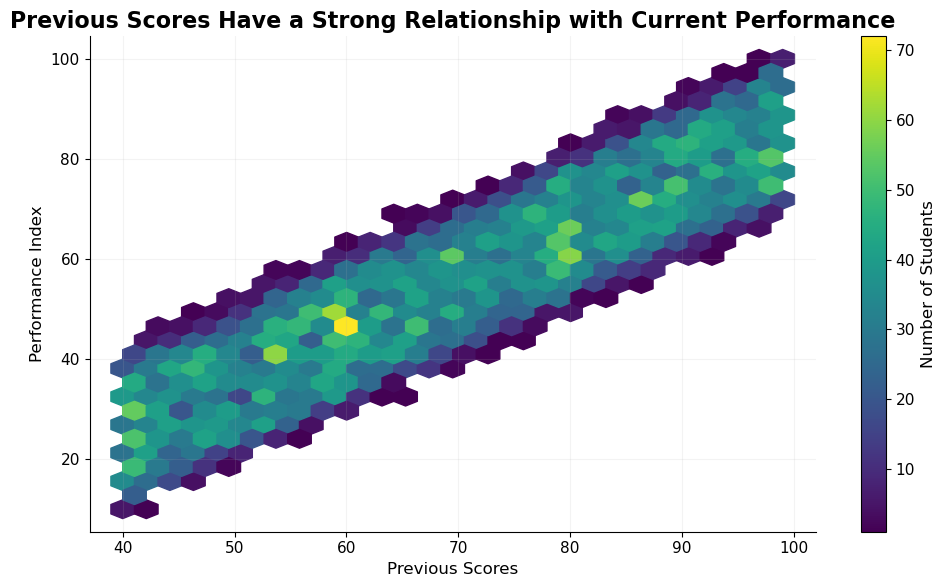

Correlation — Previous Scores vs Performance Index: 0.915
Correlation — Hours Studied vs Performance Index  : 0.375


In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
hexbin = ax.hexbin(
    df["Previous Scores"],
    df[target],
    gridsize=28,
    mincnt=1,
    cmap="viridis",)

ax.set_title("Previous Scores Have a Strong Relationship with Current Performance")
ax.set_xlabel("Previous Scores")
ax.set_ylabel("Performance Index")

cbar = fig.colorbar(hexbin, ax=ax)
cbar.set_label("Number of Students")
ax.grid(alpha=0.15)
plt.tight_layout()
plt.show()

corr_previous = df["Previous Scores"].corr(df[target])
corr_hours = df["Hours Studied"].corr(df[target])
print(f"Correlation — Previous Scores vs Performance Index: {corr_previous:.3f}")
print(f"Correlation — Hours Studied vs Performance Index  : {corr_hours:.3f}")

### Interpretation

`Previous Scores` has a much stronger linear relationship with the target (**correlation ≈ 0.915**) than `Hours Studied` (**≈ 0.374**).

This is one of the most important findings in the dataset: **past performance carries much more predictive information than study hours by themselves**. That gives us a strong reason to test multi-feature regression models later.

## 9. What Else Matters? — Correlation Heatmap

**Question:** Which numerical features are most strongly associated with the target?

A correlation heatmap gives a compact overview before we start feature experiments.

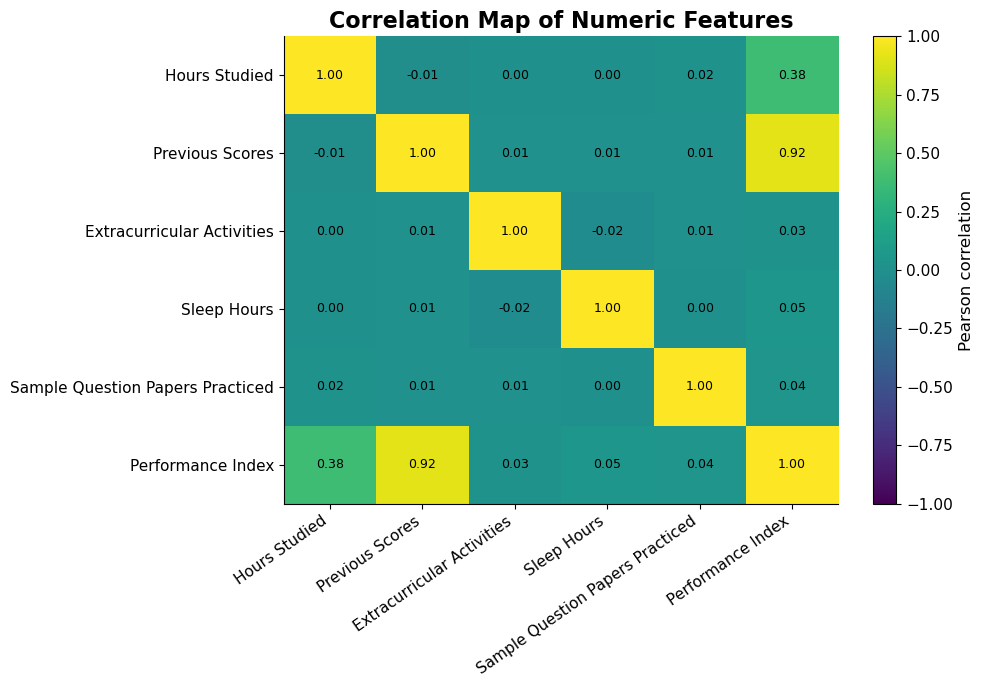

,Correlation with Performance Index
Performance Index,1.000
Previous Scores,0.915
Hours Studied,0.375
Sleep Hours,0.050
Sample Question Papers Practiced,0.043
Extracurricular Activities,0.026


In [9]:
corr = df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(corr, cmap="viridis", vmin=-1, vmax=1, aspect="auto")

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=35, ha="right")
ax.set_yticklabels(corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=9)

ax.set_title("Correlation Map of Numeric Features")
fig.colorbar(im, ax=ax, label="Pearson correlation")
plt.tight_layout()
plt.show()

target_corr = corr[target].sort_values(ascending=False)
display(target_corr.to_frame("Correlation with Performance Index").round(3))

### Interpretation

The heatmap confirms the earlier result:

- `Previous Scores` is the dominant linear relationship.
- `Hours Studied` has a moderate positive relationship.
- `Sleep Hours` and `Sample Question Papers Practiced` have much weaker individual linear correlations with the target.

Weak individual correlation does **not** automatically mean a feature is useless. That is why we still test combinations instead of rejecting features from correlation alone.

# Modeling

## 10. Train/Test Split

We reserve **20%** of the cleaned data for testing and use **80%** for training.

To make feature comparisons fair, all experiments use the **same train/test row split**.

In [10]:
target = "Performance Index"
y = df[target]

train_idx, test_idx = train_test_split(
    df.index,
    test_size=0.20,
    random_state=42,)

print(f"Training rows: {len(train_idx):,}")
print(f"Testing rows : {len(test_idx):,}")
print(f"Training share: {len(train_idx) / len(df):.1%}")
print(f"Testing share : {len(test_idx) / len(df):.1%}")

Training rows: 7,898
Testing rows : 1,975
Training share: 80.0%
Testing share : 20.0%


## 11. Evaluation Metrics

We use four regression metrics:

- **R²** → how much of the target variation the model explains. Higher is better.
- **MAE** → average absolute prediction error in Performance Index points. Lower is better.
- **RMSE** → similar to MAE, but penalizes large errors more strongly. Lower is better.
- **MAPE** → average percentage error. Lower is better.

MAPE is included because the target has **no zero values**, so there is no division-by-zero problem for this dataset.

In [11]:
def evaluate_regression(y_true, y_pred):
    return {
        "R²": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE (%)": mean_absolute_percentage_error(y_true, y_pred) * 100,}


def format_metrics(metrics):
    return pd.DataFrame([metrics]).round(3)

## 12. Required Model — Linear Regression with Hours Studied

This is the required baseline because the task specifically asks us to predict scores based on study hours.

We intentionally start simple. The question is:

> **How much can we predict using study hours alone?**

In [12]:
baseline_features = ["Hours Studied"]
X_train = df.loc[train_idx, baseline_features]
X_test = df.loc[test_idx, baseline_features]
y_train = df.loc[train_idx, target]
y_test = df.loc[test_idx, target]

baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)
baseline_pred = baseline_model.predict(X_test)

baseline_metrics = evaluate_regression(y_test, baseline_pred)
format_metrics(baseline_metrics)

,R²,MAE,RMSE,MAPE (%)
0,0.136,15.498,17.935,34.875


### Baseline interpretation

The baseline reaches only **R² ≈ 0.136**. In other words, study hours alone explain only about **13.6% of the variation** in Performance Index on the test set.

The MAE is about **15.5 points**, which is large compared with a 100-point score scale. The MAPE is also high.

This is **not a failure**. It tells us something important about the data: study time is useful, but it is far from sufficient to predict student performance accurately.

## 13. Baseline Visualization — Actual vs Predicted

For regression, a good prediction plot should place points close to the diagonal line where:

`Actual = Predicted`

We also annotate the R² value directly on the chart so the visual and numeric evaluation tell the same story.

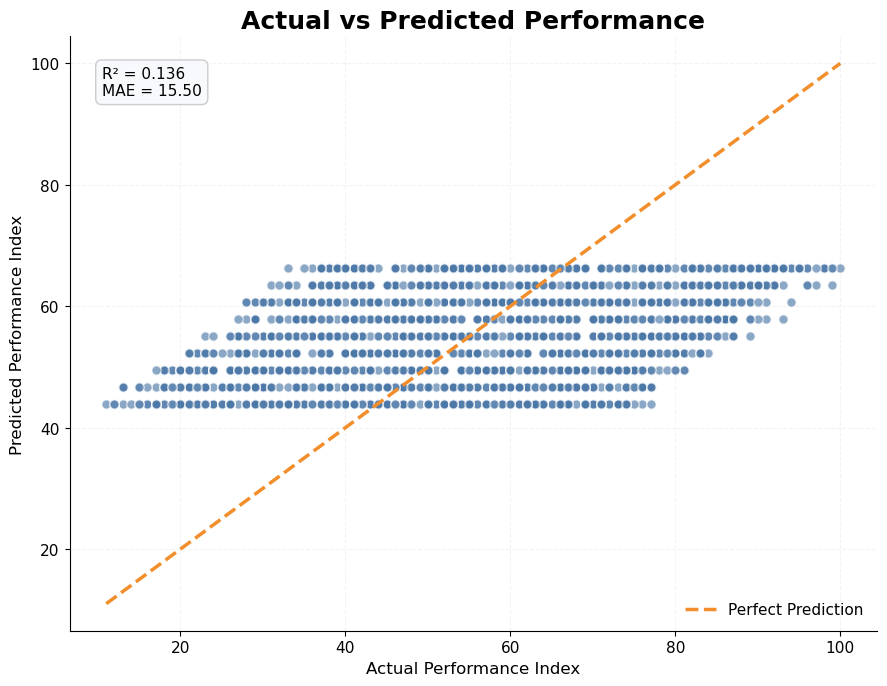

In [13]:
fig, ax = plt.subplots(figsize=(9, 7))

ax.scatter(y_test, baseline_pred, s=45, alpha=.65,
           color="#4C78A8", edgecolors="white")

vmin, vmax = min(y_test.min(), baseline_pred.min()), max(y_test.max(), baseline_pred.max())
ax.plot([vmin, vmax], [vmin, vmax], "--", color="#F28E2B", lw=2.5, label="Perfect Prediction")

ax.set_title("Actual vs Predicted Performance", fontsize=18, fontweight="bold")
ax.set_xlabel("Actual Performance Index")
ax.set_ylabel("Predicted Performance Index")
ax.legend(frameon=False)
ax.grid(alpha=.15, linestyle="--")

ax.text(.04, .95, f"R² = {baseline_metrics['R²']:.3f}\nMAE = {baseline_metrics['MAE']:.2f}",
        transform=ax.transAxes, va="top",
        bbox=dict(boxstyle="round,pad=.4", facecolor="#F7F9FC", edgecolor=".8"))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### Interpretation

The baseline points are widely scattered around the diagonal instead of forming a tight band.

That visual pattern agrees with the low R²: **knowing only the number of study hours leaves a lot of unexplained variation**.

## 14. Bonus — Polynomial Regression

A degree-2 polynomial adds a curved term to the Hours Studied relationship.

This tests whether the weak baseline is mainly caused by a curved relationship or by the fact that one feature is not enough.

Both models use the **same feature and the same test split**.

In [14]:
poly_model = Pipeline([
    ("polynomial_features", PolynomialFeatures(degree=2, include_bias=False)),
    ("linear_regression", LinearRegression())])

poly_model.fit(X_train, y_train)
poly_pred = poly_model.predict(X_test)
poly_metrics = evaluate_regression(y_test, poly_pred)

polynomial_comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Polynomial Regression (degree=2)"],
    "R²": [baseline_metrics["R²"], poly_metrics["R²"]],
    "MAE": [baseline_metrics["MAE"], poly_metrics["MAE"]],
    "RMSE": [baseline_metrics["RMSE"], poly_metrics["RMSE"]],
    "MAPE (%)": [baseline_metrics["MAPE (%)"], poly_metrics["MAPE (%)"]],})

display(polynomial_comparison.round(3))

,Model,R²,MAE,RMSE,MAPE (%)
0,Linear Regression,0.136,15.498,17.935,34.875
1,Polynomial Regression (degree=2),0.135,15.502,17.939,34.869


### Polynomial interpretation

The polynomial model is extremely close to the linear baseline, so the curvature added by degree 2 does **not** solve the main problem.

That is a useful conclusion: the biggest limitation is **missing predictive information**, not simply an overly straight line.

## 15. Bonus — Feature Combination Experiment

Now we test what happens when we add informative variables.

We compare:

1. `Hours Studied`
2. `Hours Studied + Previous Scores`
3. `Hours Studied + Previous Scores + Sleep Hours`
4. **All available features**

This directly answers which information improves prediction.

In [15]:
feature_sets = {
    "Hours Studied": ["Hours Studied"],
    "Hours + Previous Scores": ["Hours Studied", "Previous Scores"],
    "Hours + Previous + Sleep": ["Hours Studied", "Previous Scores", "Sleep Hours"],
    "All Features": [
        "Hours Studied",
        "Previous Scores",
        "Extracurricular Activities",
        "Sleep Hours",
        "Sample Question Papers Practiced",
    ],}

experiment_rows = []
predictions_by_set = {}
models_by_set = {}

for name, features in feature_sets.items():
    X_train_set = df.loc[train_idx, features]
    X_test_set = df.loc[test_idx, features]

    model = LinearRegression()
    model.fit(X_train_set, y_train)
    pred = model.predict(X_test_set)

    metrics = evaluate_regression(y_test, pred)
    experiment_rows.append({"Feature Set": name, **metrics})
    predictions_by_set[name] = pred
    models_by_set[name] = model

feature_results = pd.DataFrame(experiment_rows)
feature_results = feature_results.sort_values("R²", ascending=False).reset_index(drop=True)

display(feature_results.round(3))

,Feature Set,R²,MAE,RMSE,MAPE (%)
0,All Features,0.988,1.647,2.075,3.508
1,Hours + Previous + Sleep,0.987,1.757,2.198,3.747
2,Hours + Previous Scores,0.985,1.880,2.361,4.000
3,Hours Studied,0.136,15.498,17.935,34.875


## 16. Feature Combination Results — Visual Comparison

A compact comparison chart makes the improvement easier to see than a table alone.

The key question is not just **which model is highest**, but **how much extra predictive power each added feature provides**.

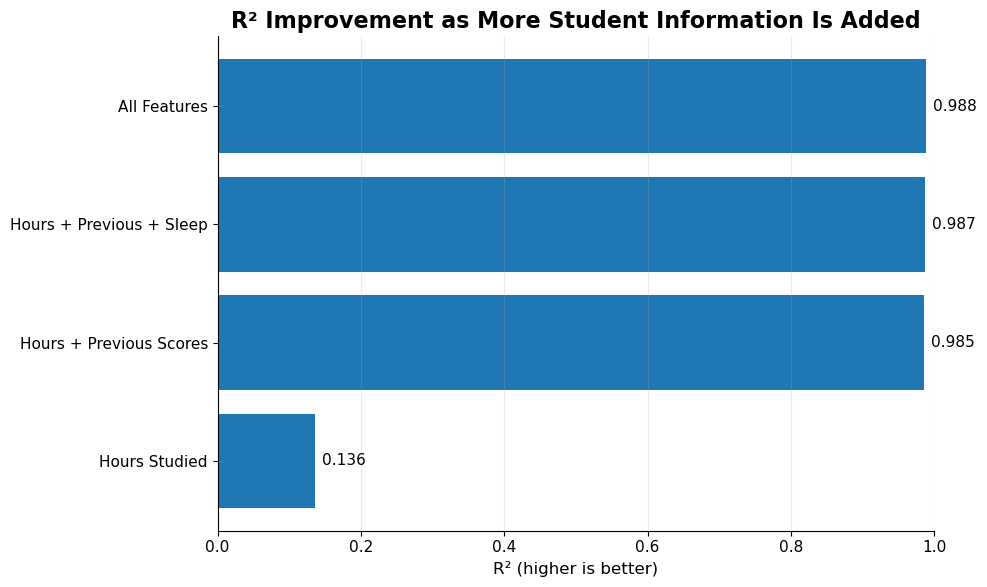

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(feature_results["Feature Set"], feature_results["R²"])
ax.invert_yaxis()
ax.set_xlim(0, 1)
ax.set_title("R² Improvement as More Student Information Is Added")
ax.set_xlabel("R² (higher is better)")
ax.set_ylabel("")
ax.grid(axis="x")

for i, value in enumerate(feature_results["R²"]):
    ax.text(value + 0.01, i, f"{value:.3f}", va="center")

plt.tight_layout()
plt.show()

### Interpretation

The feature experiment shows the largest improvement happens when **Previous Scores** is added.

Approximate test-set results after cleaning:

| Feature set | R² | MAE | RMSE | MAPE |
|---|---:|---:|---:|---:|
| Hours Studied | 0.136 | 15.50 | 17.94 | 34.87% |
| Hours + Previous Scores | 0.985 | 1.88 | 2.36 | 4.00% |
| Hours + Previous + Sleep | 0.987 | 1.76 | 2.20 | 3.75% |
| All Features | 0.988 | 1.65 | 2.08 | 3.51% |

This shows why **feature selection can matter more than model complexity** for this dataset.

## 17. Bonus — Which Features Matter in the Final Linear Model?

The best tested feature combination uses all available features.

We inspect the linear coefficients to understand the model's learned relationships.

> A coefficient describes the model's relationship while holding the other included features constant. It does **not** prove causation.

In [17]:
all_features = feature_sets["All Features"]
final_model = models_by_set["All Features"]
final_pred = predictions_by_set["All Features"]

coefficients = pd.DataFrame({
    "Feature": all_features,
    "Coefficient": final_model.coef_,})
coefficients["Absolute Coefficient"] = coefficients["Coefficient"].abs()
coefficients = coefficients.sort_values("Absolute Coefficient", ascending=False)

display(coefficients.round(3))

,Feature,Coefficient,Absolute Coefficient
0,Hours Studied,2.851,2.851
1,Previous Scores,1.018,1.018
2,Extracurricular Activities,0.574,0.574
3,Sleep Hours,0.472,0.472
4,Sample Question Papers Practiced,0.189,0.189


### Interpretation

The fitted linear model gives `Hours Studied` the largest positive **raw coefficient**, followed by `Previous Scores`. However, these coefficient magnitudes should **not** be compared directly as a measure of overall feature importance because the features use different units and ranges.

In the EDA, `Previous Scores` has the strongest individual linear relationship with the target (correlation ≈ **0.915**), while `Hours Studied` has a weaker correlation (≈ **0.375**). This means `Previous Scores` is the strongest individual predictor in terms of linear association, while `Hours Studied` has the largest raw coefficient in the multivariable fitted model.

The coefficients also show that all included features have positive fitted effects, meaning that—holding the other variables constant—higher values are associated with higher predicted Performance Index values.

## 18. Final Model Evaluation

We now report the four requested evaluation metrics for the strongest tested feature combination.

In [18]:
final_metrics = evaluate_regression(y_test, final_pred)

print("Final Linear Regression Metrics")
print("=" * 34)
print(f"R²      : {final_metrics['R²']:.4f}")
print(f"MAE     : {final_metrics['MAE']:.4f}")
print(f"RMSE    : {final_metrics['RMSE']:.4f}")
print(f"MAPE    : {final_metrics['MAPE (%)']:.2f}%")

final_metrics_table = pd.DataFrame([final_metrics], index=["All Features"])
display(final_metrics_table.round(4))

Final Linear Regression Metrics
R²      : 0.9884
MAE     : 1.6470
RMSE    : 2.0751
MAPE    : 3.51%


,R²,MAE,RMSE,MAPE (%)
All Features,0.988,1.647,2.075,3.508


### Final metric interpretation

- **R² ≈ 0.988** → the model explains about **98.8% of the variance** in the test-set Performance Index.
- **MAE ≈ 1.65** → predictions are off by about **1.65 Performance Index points on average**.
- **RMSE ≈ 2.08** → the typical error is small, while larger mistakes receive more weight.
- **MAPE ≈ 3.51%** → the average absolute percentage error is low for this positive-valued target.

Together, these metrics indicate a very strong predictive fit on the held-out test set. **R² is not an accuracy percentage**; it describes the proportion of target variance explained by the model.

## 19. Final Model — Actual vs Predicted

This visualization checks whether the strong metric performance is also visible point-by-point.

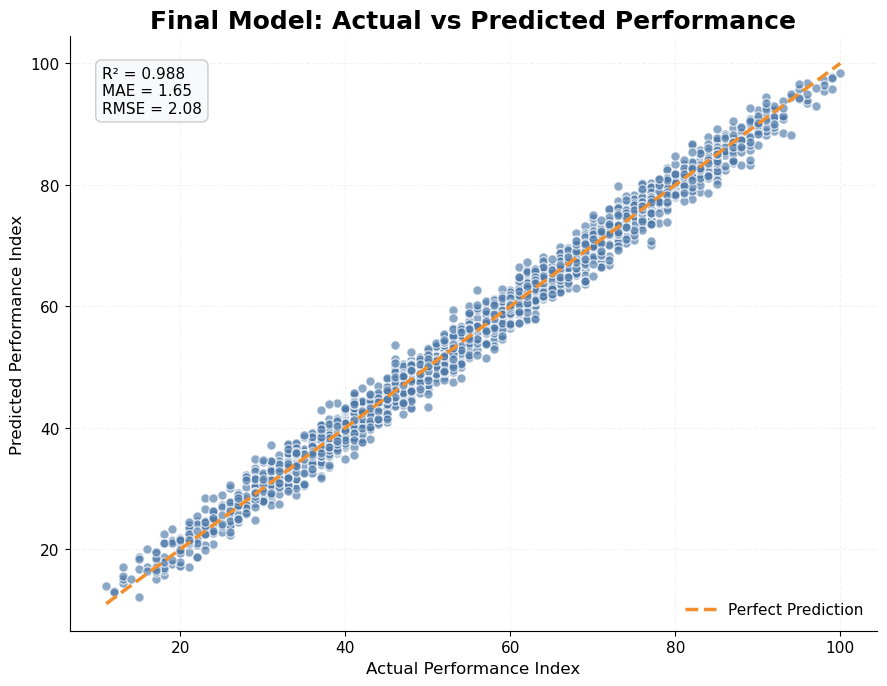

In [19]:
fig, ax = plt.subplots(figsize=(9, 7))

ax.scatter(y_test, final_pred, s=45, alpha=.65,
           color="#4C78A8", edgecolors="white")

vmin, vmax = min(y_test.min(), final_pred.min()), max(y_test.max(), final_pred.max())
ax.plot([vmin, vmax], [vmin, vmax], "--",
        color="#F28E2B", lw=2.5, label="Perfect Prediction")

ax.set_title("Final Model: Actual vs Predicted Performance",
             fontsize=18, fontweight="bold")
ax.set_xlabel("Actual Performance Index")
ax.set_ylabel("Predicted Performance Index")
ax.legend(frameon=False)
ax.grid(alpha=.15, linestyle="--")

ax.text(.04, .95,
        f"R² = {final_metrics['R²']:.3f}\n"
        f"MAE = {final_metrics['MAE']:.2f}\n"
        f"RMSE = {final_metrics['RMSE']:.2f}",
        transform=ax.transAxes, va="top",
        bbox=dict(boxstyle="round,pad=.4",
                  facecolor="#F7F9FC", edgecolor=".8"))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### Interpretation

The final predictions should form a tight cloud around the diagonal line. Compared with the baseline, the visual improvement is dramatic.

This is exactly what the metrics suggested: once previous academic performance and the other available factors are included, the linear model becomes highly accurate on the held-out test data.

## 20. Residual Analysis

A residual is:

**Residual = Actual − Predicted**

A good regression model should have residuals centered around zero, without a strong curve or funnel pattern.

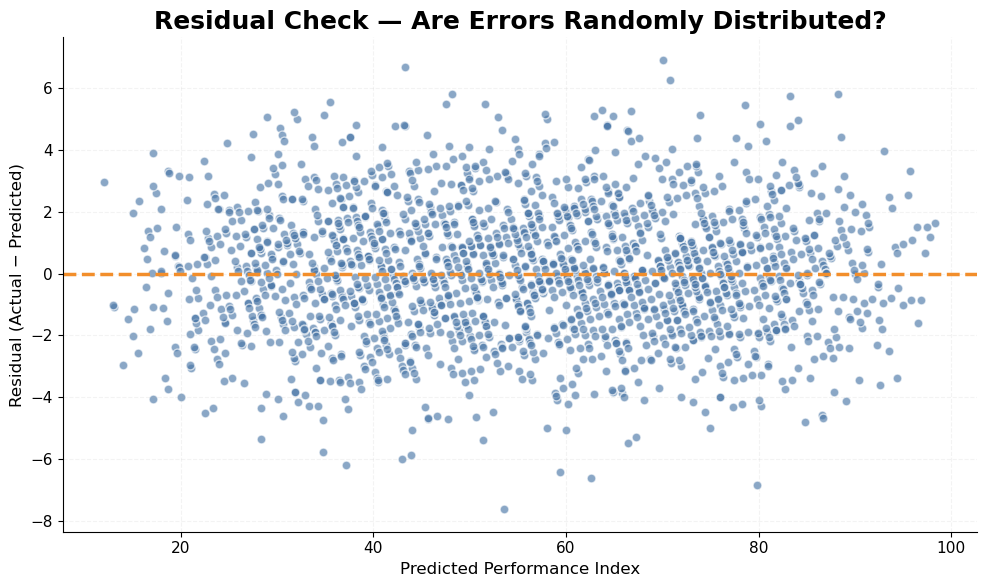

Mean residual: 0.0609
Largest absolute residual: 7.61


In [20]:
residuals = y_test - final_pred

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(final_pred, residuals, s=40, alpha=.65,
           color="#4C78A8", edgecolors="white")

ax.axhline(0, linestyle="--", color="#F28E2B", lw=2.5)

ax.set_title("Residual Check — Are Errors Randomly Distributed?",
             fontsize=18, fontweight="bold")
ax.set_xlabel("Predicted Performance Index")
ax.set_ylabel("Residual (Actual − Predicted)")

ax.grid(alpha=.15, linestyle="--")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

print(f"Mean residual: {residuals.mean():.4f}")
print(f"Largest absolute residual: {residuals.abs().max():.2f}")

### Interpretation

The residuals are centered very close to zero, with a mean residual of about **0.06**. This suggests that the final model has little overall bias toward systematically overpredicting or underpredicting the Performance Index.

The residual plot also shows errors scattered around the zero line without a strong curved or funnel-shaped pattern. That is consistent with a good linear fit and does not suggest an obvious systematic pattern left unexplained by the model.

The largest absolute residual is about **7.61 points**, showing that a small number of students are predicted less accurately than the typical case.